# Logistic Regression — Perlidae and Helicopsychidae

Binary logistic regression models for the presence/absence of the two bioindicator
taxa (*Plecoptera: Perlidae* and *Trichoptera: Helicopsychidae*) in the Cali River,
validated with leave-one-out cross-validation (LOOCV).

## 1. Introduction

Two single-predictor logistic regression models are fitted, one per bioindicator
taxon. Candidate predictors are screened by AIC over a small PCA-derived set;
`DBO5` (BOD₅) is the selected predictor for both taxa. Each model is evaluated under
LOOCV, and both calibration (training-fold) and validation (held-out) metrics are
reported. Class imbalance is handled with balanced class weights.

## 2. Dependencies and Data Loading

The macroinvertebrate dataset (n = 18) provides the physicochemical predictors and
the binary presence/absence of `Perlidae` and `Trichoptera` (Helicopsychidae).

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             precision_recall_fscore_support, accuracy_score)
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load the macroinvertebrate dataset (relative path)
df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print("Perlidae +/-:", df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", df['Trichoptera'].value_counts().to_dict())

Shape: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


## 3. Predictor Selection

Candidate predictors (`DBO5`, `Dureza`, `Caudal`) come from a 3-variable PCA. All
subsets are fitted as binomial GLMs and ranked by AIC. The single predictor `DBO5`
gives the lowest AIC and is used for both taxa.

In [3]:
# Exhaustive AIC-based subset selection for a binomial GLM (illustrated on Perlidae)
def select_model(dataframe, predictors, response):
    best_aic, best_combination = np.inf, None
    for L in range(1, len(predictors) + 1):
        for subset in combinations(predictors, L):
            X_subset = sm.add_constant(dataframe[list(subset)])
            result = sm.GLM(dataframe[response], X_subset, family=sm.families.Binomial()).fit()
            print(f"predictors {subset}: AIC = {result.aic:.3f}")
            if result.aic < best_aic:
                best_aic, best_combination = result.aic, subset
    print(f"Best subset: {best_combination} (AIC = {best_aic:.3f})")
    return best_combination

candidate_predictors = ['DBO5', 'Dureza', 'Caudal']
select_model(df, candidate_predictors, ['Perlidae'])
selected_predictor = 'DBO5'
print("Selected predictor for both taxa:", selected_predictor)

predictors ('DBO5',): AIC = 20.636
predictors ('Dureza',): AIC = 22.769
predictors ('Caudal',): AIC = 26.070
predictors ('DBO5', 'Dureza'): AIC = 21.925
predictors ('DBO5', 'Caudal'): AIC = 22.104
predictors ('Dureza', 'Caudal'): AIC = 24.411
predictors ('DBO5', 'Dureza', 'Caudal'): AIC = 23.507
Best subset: ('DBO5',) (AIC = 20.636)
Selected predictor for both taxa: DBO5


## 4. Model Definition

A standardised single-predictor logistic model with an L2 penalty and
`class_weight='balanced'`. Balancing is used because both taxa are imbalanced
(Perlidae 6/18 present; Helicopsychidae 3/18 present); without it the model would
default to predicting the majority class (absence). This follows established practice
for imbalanced ecological presence/absence data (Kuhn & Johnson, 2013).

In [4]:
# LOOCV routine returning validation (held-out) and calibration (training) predictions
def logistic_loocv(y_col):
    X = df[[selected_predictor]].values
    y = df[y_col].values
    X_scaled = StandardScaler().fit_transform(X)
    model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced')
    loo = LeaveOneOut()
    yt_val, yp_val, yt_cal, yp_cal = [], [], [], []
    for tr, te in loo.split(X_scaled):
        model.fit(X_scaled[tr], y[tr])
        yt_val.append(int(y[te][0])); yp_val.append(int(model.predict(X_scaled[te])[0]))
        yt_cal.extend(y[tr].tolist()); yp_cal.extend(model.predict(X_scaled[tr]).tolist())
    return {'yt_val': yt_val, 'yp_val': yp_val, 'yt_cal': yt_cal, 'yp_cal': yp_cal}

# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

# Fit LOOCV for both taxa
loocv = {'Perlidae': logistic_loocv('Perlidae'),
         'Helicopsychidae': logistic_loocv('Trichoptera')}
print("LOOCV complete for both taxa.")

LOOCV complete for both taxa.


## 5. Evaluation — Calibration

Calibration metrics aggregate the training-fold predictions across all LOOCV folds.

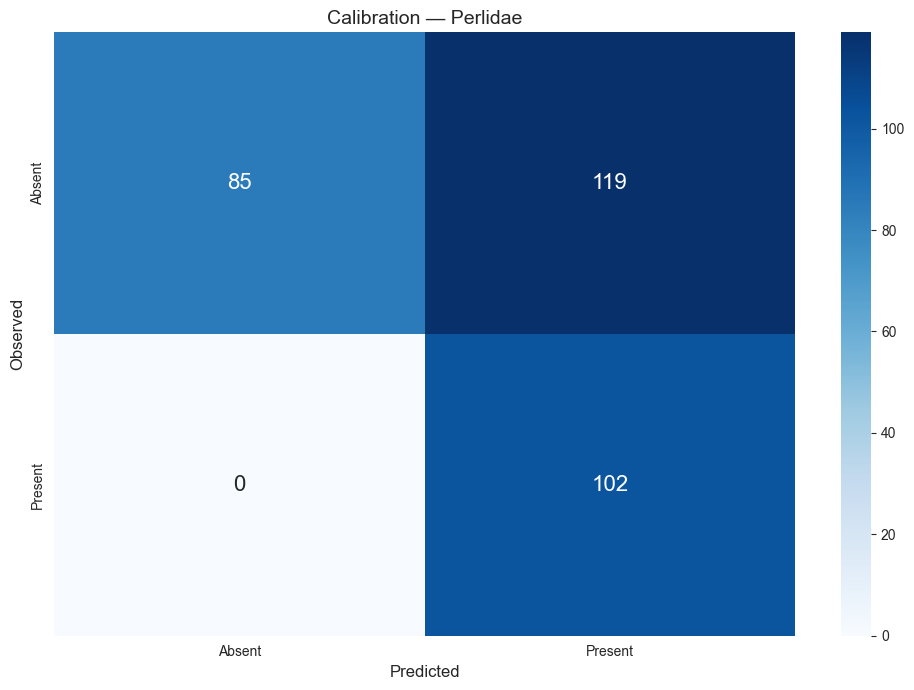

              precision    recall  f1-score   support

      Absent       1.00      0.42      0.59       204
     Present       0.46      1.00      0.63       102

    accuracy                           0.61       306
   macro avg       0.73      0.71      0.61       306
weighted avg       0.82      0.61      0.60       306

Cohen's Kappa (calibration): 0.323


In [5]:
# Perlidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Perlidae',
               'logistic_perlidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

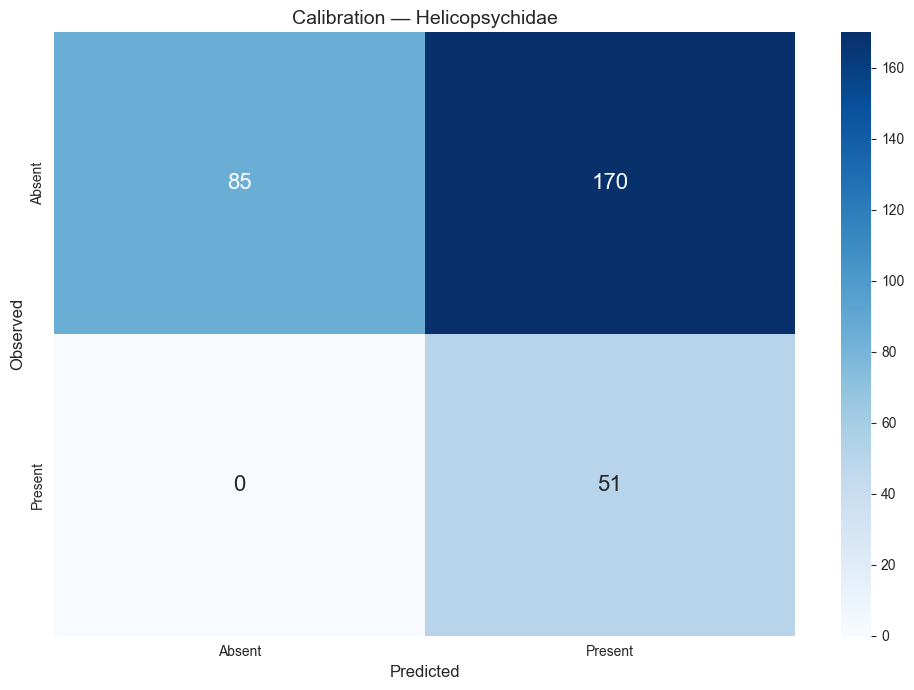

              precision    recall  f1-score   support

      Absent       1.00      0.33      0.50       255
     Present       0.23      1.00      0.38        51

    accuracy                           0.44       306
   macro avg       0.62      0.67      0.44       306
weighted avg       0.87      0.44      0.48       306

Cohen's Kappa (calibration): 0.143


In [6]:
# Helicopsychidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Helicopsychidae',
               'logistic_helicopsychidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

## 6. Evaluation — Validation (LOOCV)

Validation metrics use the held-out observation from each fold — the honest estimate
of out-of-sample performance.

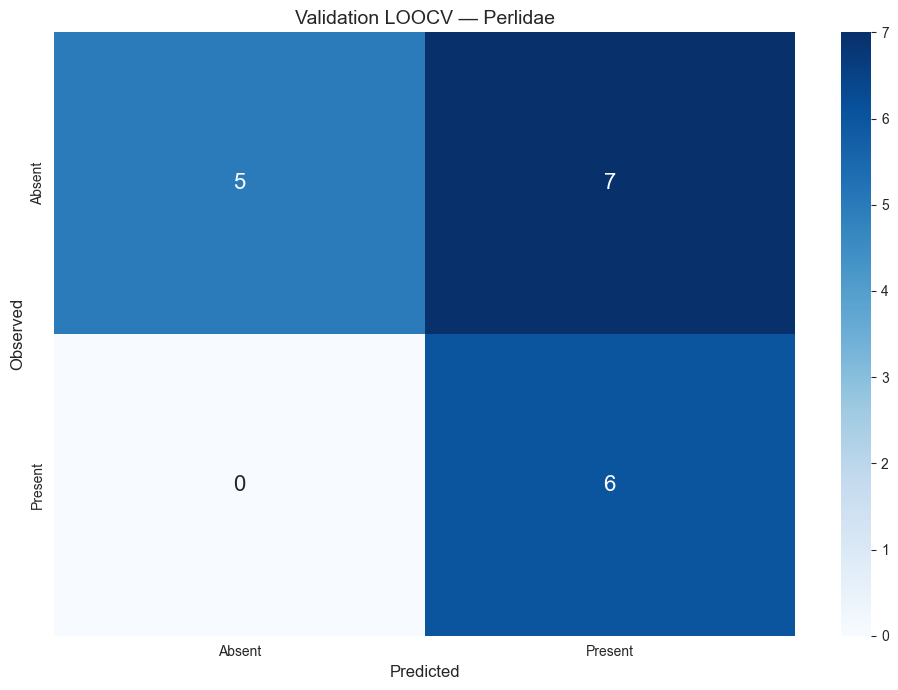

              precision    recall  f1-score   support

      Absent       1.00      0.42      0.59        12
     Present       0.46      1.00      0.63         6

    accuracy                           0.61        18
   macro avg       0.73      0.71      0.61        18
weighted avg       0.82      0.61      0.60        18

Cohen's Kappa (validation): 0.323


In [7]:
# Perlidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Perlidae',
               'logistic_perlidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

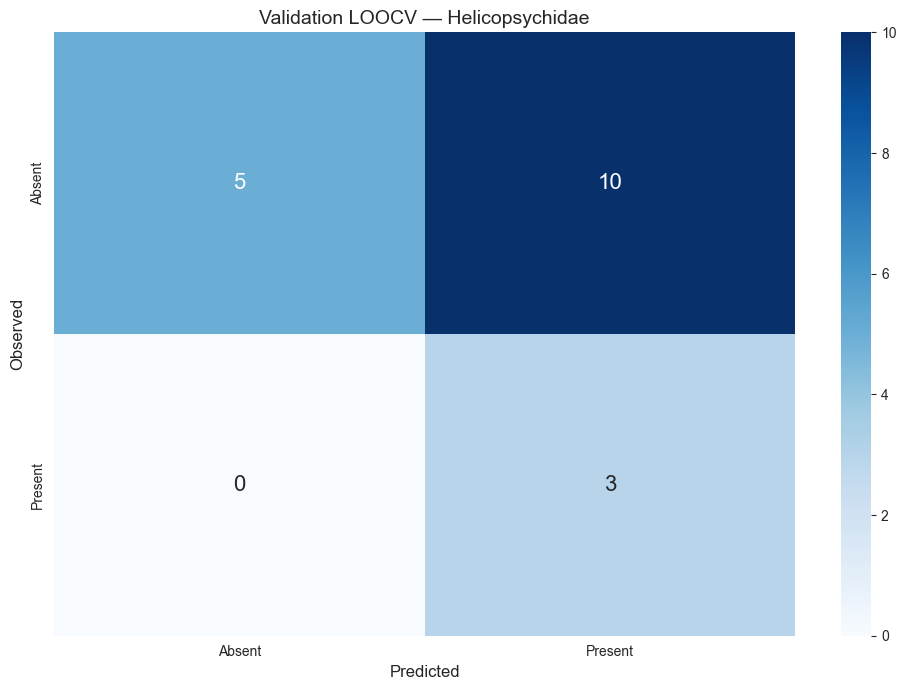

              precision    recall  f1-score   support

      Absent       1.00      0.33      0.50        15
     Present       0.23      1.00      0.38         3

    accuracy                           0.44        18
   macro avg       0.62      0.67      0.44        18
weighted avg       0.87      0.44      0.48        18

Cohen's Kappa (validation): 0.143


In [8]:
# Helicopsychidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Helicopsychidae',
               'logistic_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

### Note on Helicopsychidae performance

With only 3 presences of 18 (17 %), LOOCV cannot reliably estimate minority-class
generalisation. The validation results for this taxon should be read with caution;
Cohen's κ is the most informative single metric under such imbalance.

## 8. Visualisation

Fitted logistic probability curves (presence probability vs BOD₅) for each taxon,
refitted on the full sample for display.

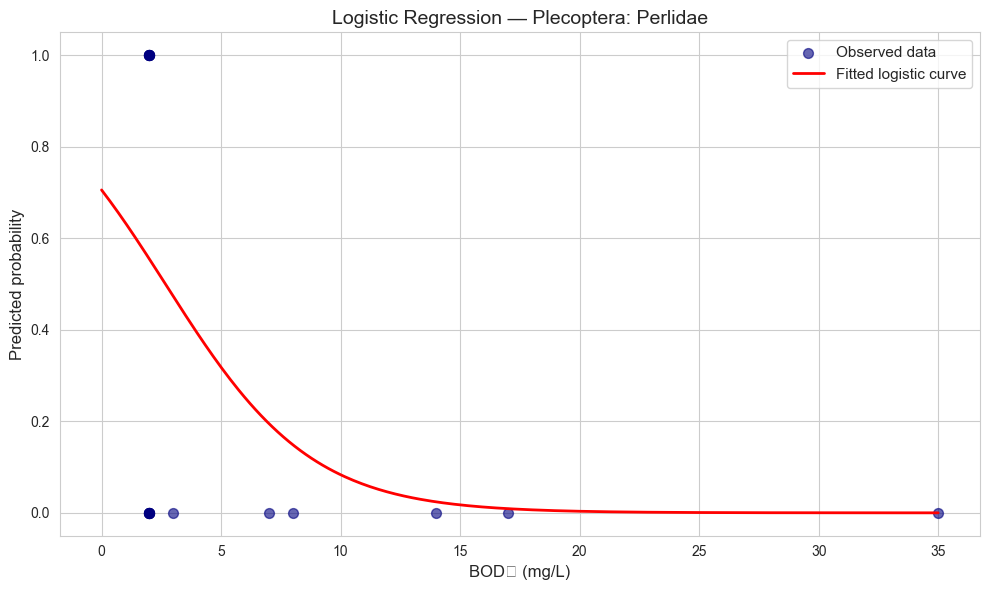

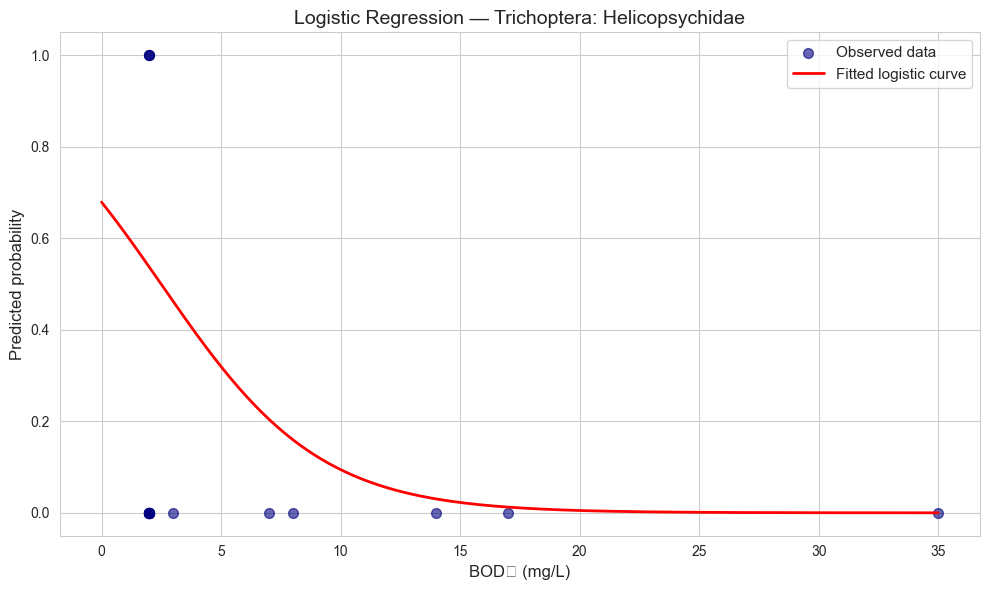

In [9]:
# Helper: fit a single-predictor logistic model on raw DBO5 and plot the fitted curve
def plot_logistic_curve(y_col, taxon, filename):
    X = df[[selected_predictor]].values
    y = df[y_col].values
    model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced').fit(X, y)
    b0 = model.intercept_[0]; b1 = model.coef_[0][0]
    x_grid = np.linspace(0, df[selected_predictor].max(), 300)
    p_grid = 1 / (1 + np.exp(-(b0 + b1 * x_grid)))
    plt.figure(figsize=(10, 6))
    plt.scatter(df[selected_predictor], y, color='navy', alpha=0.6, s=50, label='Observed data')
    plt.plot(x_grid, p_grid, color='red', linewidth=2, label='Fitted logistic curve')
    plt.title(f'Logistic Regression — {taxon}', fontsize=14)
    plt.xlabel('BOD₅ (mg/L)', fontsize=12); plt.ylabel('Predicted probability', fontsize=12)
    plt.legend(fontsize=11)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

plot_logistic_curve('Perlidae', 'Plecoptera: Perlidae', 'logistic_curve_perlidae.png')
plot_logistic_curve('Trichoptera', 'Trichoptera: Helicopsychidae', 'logistic_curve_helicopsychidae.png')

In [10]:
# Export validation metrics for the master results table
rows = []
for taxon in ['Perlidae', 'Helicopsychidae']:
    res = loocv[taxon]
    p, r, f, _ = precision_recall_fscore_support(res['yt_val'], res['yp_val'], labels=[0, 1],
                                                 average='macro', zero_division=0)
    rows.append({'target': taxon, 'technique': 'Logistic regression', 'validation': 'LOOCV', 'n': 18,
                 'precision': round(p, 3), 'recall': round(r, 3), 'f1': round(f, 3),
                 'accuracy': round(accuracy_score(res['yt_val'], res['yp_val']), 3),
                 'kappa': round(cohen_kappa_score(res['yt_val'], res['yp_val']), 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_logistic.csv", index=False)
print("Saved outputs/metrics_logistic.csv")
print(pd.DataFrame(rows).to_string(index=False))

Saved outputs/metrics_logistic.csv
         target           technique validation  n  precision  recall    f1  accuracy  kappa
       Perlidae Logistic regression      LOOCV 18      0.731   0.708 0.610     0.611  0.323
Helicopsychidae Logistic regression      LOOCV 18      0.615   0.667 0.438     0.444  0.143


### Nested LOOCV comparison

In the validation above, AIC selected the predictor set **once on the full
dataset** (`DBO5`) before LOOCV. Nested LOOCV removes this residual leakage by
re-running the exhaustive AIC subset selection **inside each fold**, using only
the n-1 training observations, over the same candidate set
(`DBO5`, `Dureza`, `Caudal`). The fold-specific predictors then feed a balanced
logistic model fitted on the training rows and evaluated on the held-out station.

Below, the per-fold predictor selection is shown for each taxon (a stability
check) followed by a side-by-side comparison of standard vs nested LOOCV metrics.
Nested metrics are exported to `outputs/metrics_logistic_nested_loocv.csv`.

In [11]:
# Nested LOOCV: AIC subset selection re-run inside each fold on training data only
from itertools import combinations
from collections import Counter
from IPython.display import Markdown, display

def select_by_aic_nested(train_df, candidates, response):
    # Exhaustive AIC subset selection for a binomial GLM, fitted on training data only
    best_aic, best_combo = np.inf, None
    for L in range(1, len(candidates) + 1):
        for subset in combinations(candidates, L):
            X_tr = sm.add_constant(train_df[list(subset)])
            y_tr = train_df[response]
            try:
                result = sm.GLM(y_tr, X_tr, family=sm.families.Binomial()).fit()
                if result.aic < best_aic:
                    best_aic, best_combo = result.aic, subset
            except Exception:
                continue
    return list(best_combo)

def logistic_loocv_nested(y_col):
    # LOOCV with nested AIC predictor selection and a balanced logistic model per fold
    loo = LeaveOneOut()
    yt_val, yp_val, sel = [], [], []
    for tr, te in loo.split(np.arange(len(df))):
        train = df.iloc[tr]
        selected = select_by_aic_nested(train, candidate_predictors, y_col)   # nested selection
        sel.append(selected)
        scaler = StandardScaler().fit(train[selected].values)
        X_tr = scaler.transform(train[selected].values)
        X_te = scaler.transform(df.iloc[te][selected].values)
        model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                                   random_state=42, class_weight='balanced').fit(X_tr, train[y_col].values)
        yt_val.append(int(df.iloc[te][y_col].values[0]))
        yp_val.append(int(model.predict(X_te)[0]))
    return {'yt_val': yt_val, 'yp_val': yp_val, 'sel': sel}

nested = {'Perlidae': logistic_loocv_nested('Perlidae'),
          'Helicopsychidae': logistic_loocv_nested('Trichoptera')}
print("Nested LOOCV complete for both taxa.")

Nested LOOCV complete for both taxa.


In [12]:
# Predictor stability per fold and nested-vs-standard metric comparison
def met(yt, yp):
    # Macro precision/recall/F1, accuracy and Cohen's kappa for binary predictions
    p, r, f, _ = precision_recall_fscore_support(yt, yp, labels=[0, 1], average='macro', zero_division=0)
    return dict(precision=p, recall=r, f1=f, accuracy=accuracy_score(yt, yp),
                kappa=cohen_kappa_score(yt, yp))

rows_out = []
lines = ['| Taxon | Metric | Standard LOOCV | Nested LOOCV | Difference |',
         '|-------|--------|----------------|--------------|------------|']
for taxon, y_col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
    std = met(loocv[taxon]['yt_val'], loocv[taxon]['yp_val'])      # standard LOOCV (DBO5 fixed)
    nst = met(nested[taxon]['yt_val'], nested[taxon]['yp_val'])    # nested LOOCV (AIC per fold)
    sel = nested[taxon]['sel']
    mat = pd.DataFrame({'Fold': range(1, len(sel) + 1),
                        'Selected predictors': ['+'.join(s) for s in sel]})
    modal = Counter(tuple(s) for s in sel).most_common(1)[0]
    dbo_only = sum(1 for s in sel if s == ['DBO5'])
    print(f"=== {taxon}: modal set {modal[0]} in {modal[1]}/{len(sel)} folds; "
          f"DBO5-only in {dbo_only}/{len(sel)} folds ===")
    display(mat)
    for m in ['accuracy', 'kappa']:
        lines.append(f"| {taxon} | {m.capitalize()} | {std[m]:.3f} | {nst[m]:.3f} | {nst[m] - std[m]:+.3f} |")
    rows_out.append({'target': taxon, 'technique': 'Logistic regression', 'validation': 'Nested LOOCV',
                     'n': 18, 'precision': round(nst['precision'], 3), 'recall': round(nst['recall'], 3),
                     'f1': round(nst['f1'], 3), 'accuracy': round(nst['accuracy'], 3),
                     'kappa': round(nst['kappa'], 3), 'modal_predictors': '+'.join(modal[0]),
                     'predictor_stability': f"{modal[1]}/{len(sel)}"})
display(Markdown('\n'.join(lines)))
pd.DataFrame(rows_out).to_csv("../../outputs/metrics_logistic_nested_loocv.csv", index=False)
print("Saved outputs/metrics_logistic_nested_loocv.csv")

=== Perlidae: modal set ('DBO5',) in 16/18 folds; DBO5-only in 16/18 folds ===


,Fold,Selected predictors
0,1,DBO5
1,2,DBO5
2,3,DBO5
3,4,DBO5
4,5,DBO5
5,6,DBO5
6,7,DBO5
7,8,DBO5
8,9,DBO5
9,10,DBO5


=== Helicopsychidae: modal set ('Caudal',) in 10/18 folds; DBO5-only in 1/18 folds ===


,Fold,Selected predictors
0,1,DBO5+Caudal
1,2,Caudal
2,3,Caudal
3,4,Caudal
4,5,Caudal
5,6,DBO5+Caudal
6,7,Caudal
7,8,Caudal
8,9,DBO5+Caudal
9,10,Caudal


| Taxon | Metric | Standard LOOCV | Nested LOOCV | Difference |
|-------|--------|----------------|--------------|------------|
| Perlidae | Accuracy | 0.611 | 0.556 | -0.056 |
| Perlidae | Kappa | 0.323 | 0.200 | -0.123 |
| Helicopsychidae | Accuracy | 0.444 | 0.611 | +0.167 |
| Helicopsychidae | Kappa | 0.143 | 0.276 | +0.133 |

Saved outputs/metrics_logistic_nested_loocv.csv


## 9. Limitations

- **Very small sample** (n = 18) with strong class imbalance (Helicopsychidae 3/18
  present); validation metrics have wide uncertainty and one observation can move a
  score.
- **Single predictor.** AIC selects `DBO5` alone; richer relationships cannot be
  captured by a one-variable logistic model, and the wide coefficient standard errors
  reflect quasi-separation in this small sample.
- **Spatial non-independence.** Stations lie along one river, so LOOCV folds are not
  fully independent.
- **Class balancing.** `class_weight='balanced'` improves minority-class recall but
  can inflate false positives, particularly for the rare Helicopsychidae taxon.

## 10. Predictor Selection Sensitivity: AIC vs Spearman

To evaluate whether Spearman-based predictor selection changes logistic regression
validation performance for each taxon, a parallel nested LOOCV is run with the
Spearman |rs| rule. All other settings match the nested AIC LOOCV above: same
balanced logistic model (L2, liblinear, class_weight=balanced), same StandardScaler,
same candidate set (DBO5, Dureza, Caudal).

**Spearman selection rule (same as Notebook 03b):** inside each fold, using only the
n-1 training observations: (1) compute |rs| for each candidate predictor vs the
binary target; (2) retain predictors with |rs| ≥ 0.3; (3) if fewer than 2 pass,
keep the top-2; (4) if more than 3 pass, keep only the top-3.


In [13]:
from scipy.stats import spearmanr
from collections import Counter
from IPython.display import Markdown, display

# ── Spearman selection helper ──────────────────────────────────────────────────
def select_by_spearman_logistic(train_df, candidates, response):
    rs_abs = {c: abs(spearmanr(train_df[c], train_df[response])[0]) for c in candidates}
    sorted_preds = sorted(rs_abs, key=rs_abs.get, reverse=True)
    passing = [p for p in sorted_preds if rs_abs[p] >= 0.3]
    if len(passing) < 2:
        return sorted_preds[:2]
    if len(passing) > 3:
        return sorted_preds[:3]
    return passing

# ── Spearman-based nested LOOCV (same balanced logistic model) ─────────────────
def logistic_loocv_spearman(y_col):
    yt_val, yp_val, sel = [], [], []
    for tr, te in LeaveOneOut().split(np.arange(len(df))):
        train_fold = df.iloc[tr]
        sel_f = select_by_spearman_logistic(train_fold, candidate_predictors, y_col)
        sel.append(sel_f)
        scaler = StandardScaler().fit(train_fold[sel_f].values)
        X_tr = scaler.transform(train_fold[sel_f].values)
        X_te = scaler.transform(df.iloc[te][sel_f].values)
        m = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced').fit(X_tr, train_fold[y_col].values)
        yt_val.append(int(df.iloc[te][y_col].values[0]))
        yp_val.append(int(m.predict(X_te)[0]))
    return {'yt_val': yt_val, 'yp_val': yp_val, 'sel': sel}

nested_sp = {'Perlidae':        logistic_loocv_spearman('Perlidae'),
             'Helicopsychidae': logistic_loocv_spearman('Trichoptera')}
print("Spearman-based nested LOOCV complete for both taxa.")

# ── Metrics comparison and predictor stability per taxon ───────────────────────
rows_csv = []
md_lines = [
    '| Taxon | Selection | Accuracy | Kappa | Precision | Recall | F1 | Notes |',
    '|-------|-----------|----------|-------|-----------|--------|----|-------|',
]

for taxon, y_col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
    m_aic = met(nested[taxon]['yt_val'], nested[taxon]['yp_val'])
    m_sp  = met(nested_sp[taxon]['yt_val'], nested_sp[taxon]['yp_val'])
    sel_aic_t = nested[taxon]['sel']
    sel_sp_t  = nested_sp[taxon]['sel']
    modal_aic_t = Counter(tuple(s) for s in sel_aic_t).most_common(1)[0]
    modal_sp_t  = Counter(tuple(s) for s in sel_sp_t).most_common(1)[0]
    pfreq_aic_t = {p: sum(1 for s in sel_aic_t if p in s) for p in candidate_predictors}
    pfreq_sp_t  = {p: sum(1 for s in sel_sp_t  if p in s) for p in candidate_predictors}

    stab_t = pd.DataFrame({
        'Predictor':               candidate_predictors,
        'AIC folds (of 18)':      [pfreq_aic_t[p] for p in candidate_predictors],
        'Spearman folds (of 18)': [pfreq_sp_t[p]  for p in candidate_predictors],
    })
    print(f"=== {taxon}: Predictor Stability AIC vs Spearman ===")
    display(stab_t)
    print(f"Modal AIC:      {modal_aic_t[0]}  ×{modal_aic_t[1]}/18")
    print(f"Modal Spearman: {modal_sp_t[0]}  ×{modal_sp_t[1]}/18")
    print(f"Modal set changed: {set(modal_aic_t[0]) != set(modal_sp_t[0])}\n")

    md_lines.append(
        f"| {taxon} | AIC      | {m_aic['accuracy']:.3f} | {m_aic['kappa']:.3f} | "
        f"{m_aic['precision']:.3f} | {m_aic['recall']:.3f} | {m_aic['f1']:.3f} | "
        f"modal: {'+'.join(modal_aic_t[0])} ×{modal_aic_t[1]} |")
    md_lines.append(
        f"| {taxon} | Spearman | {m_sp['accuracy']:.3f} | {m_sp['kappa']:.3f} | "
        f"{m_sp['precision']:.3f} | {m_sp['recall']:.3f} | {m_sp['f1']:.3f} | "
        f"modal: {'+'.join(modal_sp_t[0])} ×{modal_sp_t[1]} |")

    for crit, m_vals, modal_t in [('AIC', m_aic, modal_aic_t), ('Spearman', m_sp, modal_sp_t)]:
        rows_csv.append({
            'model': 'Logistic', 'target': taxon, 'selection_criterion': crit,
            'validation': 'Nested LOOCV', 'accuracy': round(m_vals['accuracy'], 3),
            'kappa': round(m_vals['kappa'], 3), 'mae': None, 'rmse': None,
            'r2': None, 'spearman_rs': None, 'modal_predictors': '+'.join(modal_t[0]),
            'predictor_stability': f"{modal_t[1]}/18",
        })

display(Markdown('\n'.join(md_lines)))
pd.DataFrame(rows_csv).to_csv("../../outputs/sensitivity_logistic_aic_vs_spearman.csv", index=False)
print("Saved outputs/sensitivity_logistic_aic_vs_spearman.csv")


Spearman-based nested LOOCV complete for both taxa.
=== Perlidae: Predictor Stability AIC vs Spearman ===


,Predictor,AIC folds (of 18),Spearman folds (of 18)
0,DBO5,18,18
1,Dureza,1,18
2,Caudal,1,0


Modal AIC:      ('DBO5',)  ×16/18
Modal Spearman: ('DBO5', 'Dureza')  ×16/18
Modal set changed: True

=== Helicopsychidae: Predictor Stability AIC vs Spearman ===


,Predictor,AIC folds (of 18),Spearman folds (of 18)
0,DBO5,7,17
1,Dureza,1,1
2,Caudal,17,18


Modal AIC:      ('Caudal',)  ×10/18
Modal Spearman: ('Caudal', 'DBO5')  ×17/18
Modal set changed: True



| Taxon | Selection | Accuracy | Kappa | Precision | Recall | F1 | Notes |
|-------|-----------|----------|-------|-----------|--------|----|-------|
| Perlidae | AIC      | 0.556 | 0.200 | 0.625 | 0.625 | 0.556 | modal: DBO5 ×16 |
| Perlidae | Spearman | 0.611 | 0.276 | 0.656 | 0.667 | 0.610 | modal: DBO5+Dureza ×16 |
| Helicopsychidae | AIC      | 0.611 | 0.276 | 0.650 | 0.767 | 0.579 | modal: Caudal ×10 |
| Helicopsychidae | Spearman | 0.667 | 0.217 | 0.597 | 0.667 | 0.585 | modal: Caudal+DBO5 ×17 |

Saved outputs/sensitivity_logistic_aic_vs_spearman.csv
